In [21]:
import numpy as np

In [22]:
import kagglehub
import pathlib
from pathlib import Path

In [23]:
import pandas as pd

In [44]:
import json
import re
from typing import List
from collections import Counter

from pydantic import BaseModel, Field
from tqdm import tqdm

In [195]:
from pydantic import BaseModel
from typing import List

# DEFINE LLM (GROQ API)

##### This project used an open-source Groq API.

In [ ]:
import os
import langchain_groq
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = YOUR_API_KEY
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
)

In [45]:
def call_llm(prompt):
    response = llm.invoke(prompt)
    return response.content

In [46]:
def clean_json_response(response):

    response = response.replace("```json", "")
    response = response.replace("```", "")

    match = re.search(
        r"\{.*\}",
        response,
        re.DOTALL
    )

    if match:
        return match.group(0)

    raise ValueError(
        "No JSON object found"
    )

# DEFINE DATASET

In [201]:
handle = "entenam/reddit-mental-health-dataset" #open-source Kaggle dataset

dataset_dir = Path(kagglehub.dataset_download(handle))
csv_files = sorted(dataset_dir.rglob("*.csv"))

In [25]:
df = pd.read_csv(csv_files[0], low_memory=False)

In [26]:
df.head()

,score,selftext,subreddit,title,Label
0,1.0,Tried to watch this documentary “anxious Ameri...,Anxiety,Do people get over anxiety?,Drug and Alcohol
1,1.0,"i’m currently laying in bed wide awake, feelin...",Anxiety,does anyone else have this big fear of suddenl...,Drug and Alcohol
2,2.0,Second time trying weed. First time felt close...,Anxiety,3 hour long panic attack after trying weed,Drug and Alcohol
3,1.0,"I am not posting this for me, but rather for m...",Anxiety,Please leave in the comments ANYTHING that has...,Drug and Alcohol
4,1.0,21 year old male been dealing with anxiety eve...,Anxiety,Alcohol induced,Drug and Alcohol


# STRUCTURED OUTPUTS (SCHEMAS)

In [ ]:
class NarrativeAnalysis(BaseModel):

    emotions: List[str] = Field(default_factory=list)

    challenges: List[str] = Field(default_factory=list)

    coping_strategies: List[str] = Field(default_factory=list)

    protective_factors: List[str] = Field(default_factory=list)

    therapeutic_needs: List[str] = Field(default_factory=list)


class BehaviouralAnalysis(BaseModel):

    mechanisms: List[str] = Field(default_factory=list)

    explanation: str = ""

    uncertainty: str = ""


class Intervention(BaseModel):

    name: str = ""

    rationale: str = ""


class InterventionSuggestion(BaseModel):

    interventions: List[Intervention] = Field(
        default_factory=list
    )

    confidence: float = 0.0


class EvidenceQuote(BaseModel):

    quote: str = ""

    reason: str = ""


class EvidenceTrace(BaseModel):

    supporting_quotes: List[EvidenceQuote] = Field(
        default_factory=list
    )

    explanation: str = ""


class Hypothesis(BaseModel):

    hypothesis: str = ""


class Limitation(BaseModel):

    limitation: str = ""

    reason: str = ""


class ResearchHypothesisWithoutRationale(BaseModel):

    hypotheses: List[Hypothesis] = Field(
        default_factory=list
    )

    limitations: List[Limitation] = Field(
        default_factory=list
    )


"""class EvidenceItem(BaseModel):
    quote: str = ""
    interpretation: str = ""


class ResearchHypothesis(BaseModel):

    hypothesis: str = ""

    rationale: str = ""

    supporting_patterns: List[str] = Field(
        default_factory=list
    )

    supporting_evidence: List[EvidenceItem] = Field(
        default_factory=list
    )

    research_value: str = ""
    """

"""class EvidenceItem(BaseModel):

    quote: str

    interpretation: str


class HypothesisItem(BaseModel):

    hypothesis: str

    rationale: str

    supporting_patterns: List[str]

    supporting_evidence: List[EvidenceItem]

    research_value: str


class ResearchHypotheses(BaseModel):

    hypotheses: List[HypothesisItem]"""
# new class for explainable research hypothesis generator below

In [ ]:
# List from typing
# BaseModel for pydantic

class EvidenceItemNew(BaseModel):
    quote: str
    interpretation: str


class HypothesisItemNew(BaseModel):
    hypothesis: str
    rationale: str
    supporting_patterns: List[str]
    supporting_evidence: List[EvidenceItemNew]
    research_value: str


class ResearchHypothesesNew(BaseModel):
    hypotheses: List[HypothesisItemNew]

# AGENTS

## Narrative analysis agent

In [48]:
def narrative_analysis_agent(text):

    prompt = f"""
You are a qualitative mental health researcher.

Analyse this first-person Reddit mental health narrative.

Extract:

- emotions
- challenges
- coping strategies
- protective factors
- therapeutic needs

Do not diagnose.

Return ONLY JSON:

{{
"emotions": [],
"challenges": [],
"coping_strategies": [],
"protective_factors": [],
"therapeutic_needs": []
}}

Narrative:

{text}
"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return NarrativeAnalysis.model_validate_json(response)

## Behavioural mechanisms agent

In [49]:
def behavioural_mechanism_agent(narrative):

    prompt = f"""
You are a behavioural psychology researcher.

Analyse this qualitative summary:

{narrative}

Identify possible behavioural mechanisms.

Examples:
- avoidance
- rumination
- social withdrawal
- emotion regulation difficulties
- coping patterns

Do not diagnose.

Return ONLY JSON:

{{
"mechanisms": [],
"explanation": "",
"uncertainty": ""
}}
"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return BehaviouralAnalysis.model_validate_json(response)

## Intervention mapping agent

In [59]:
def intervention_mapping_agent(
    narrative,
    mechanisms
):

    prompt = f"""
You support development of AI-assisted mental health tools.

Given:

Narrative:
{narrative}

Behavioural mechanisms:
{mechanisms}

Suggest possible evidence-informed psychological approaches.

These are research hypotheses only,
not treatment recommendations.

Return ONLY JSON:

{{
"interventions": [],
"rationale": "",
"confidence": 0.0
}}
"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return InterventionSuggestion.model_validate_json(response)

## Evidence traceability agent

In [65]:
def evidence_trace_agent(
    text,
    interventions
):

    prompt = f"""
You are checking an AI qualitative analysis.

Original narrative:

{text}

Suggested approaches:

{interventions}

Extract exact phrases from the narrative that support the interpretation.

For EVERY quote, explain why it is relevant.

Return ONLY JSON in this exact format:

{{
"supporting_quotes": [
    {{
        "quote": "exact text from the narrative",
        "reason": "why this quote supports the interpretation"
    }}
],
"explanation": "overall explanation of how the evidence supports the analysis"
}}

Do not leave any field empty.
"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return EvidenceTrace.model_validate_json(response)

## Research hypothesis agent

In [134]:
def research_hypothesis_agent_without_rationale(summary):

    prompt = f"""
You are a mental health researcher.

Based on these aggregated qualitative findings:

{summary}

Generate possible research hypotheses.

Do not present conclusions.

Return ONLY JSON:

{{
"hypotheses": [],
"limitations": []
}}

"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return ResearchHypothesisWithoutRationale.model_validate_json(response)

##### An additional research hypothesis agent with explanation of its rationale was added.

In [154]:
def research_hypothesis_agent_with_rationale(summary):

    prompt = f"""

You are a mental health researcher analysing qualitative patient narratives.

Based on the following analysis summary:

{summary}

Generate 3-5 distinct research hypotheses.

For EACH hypothesis provide:

1. The research hypothesis
2. Why this hypothesis emerged from the qualitative data
3. Behavioural or psychological patterns supporting it
4. Direct evidence examples from the narratives
5. Why this hypothesis could be scientifically valuable

Important:
- Do not claim causality.
- These are hypotheses for future empirical testing.
- Every evidence quote must include an explanation of why it supports the hypothesis.
- Do not leave any field empty.

Return ONLY JSON:

{{
"hypotheses": [
    {{
    "hypothesis": "",
    "rationale": "",
    "supporting_patterns": [],
    "supporting_evidence": [
        {{
        "quote": "",
        "interpretation": ""
        }}
    ],
    "research_value": ""
    }}
]
}}

"""

    response = call_llm(prompt)

    response = clean_json_response(response)

    return ResearchHypothesesNew.model_validate_json(response)

# ANALYSING REPORTS

In [53]:
df = df[
    df["selftext"].notna()
].copy()


df = df[
    df["selftext"].str.len() > 100
].copy()


df.head()

,score,selftext,subreddit,title,Label
0,1.0,Tried to watch this documentary “anxious Ameri...,Anxiety,Do people get over anxiety?,Drug and Alcohol
1,1.0,"i’m currently laying in bed wide awake, feelin...",Anxiety,does anyone else have this big fear of suddenl...,Drug and Alcohol
2,2.0,Second time trying weed. First time felt close...,Anxiety,3 hour long panic attack after trying weed,Drug and Alcohol
3,1.0,"I am not posting this for me, but rather for m...",Anxiety,Please leave in the comments ANYTHING that has...,Drug and Alcohol
4,1.0,21 year old male been dealing with anxiety eve...,Anxiety,Alcohol induced,Drug and Alcohol


In [36]:
df.columns

Index(['score', 'selftext', 'subreddit', 'title', 'Label'], dtype='str')

In [37]:
df = df[
    df["selftext"].notna()
].copy()

In [54]:
sample = df.iloc[0]["selftext"]

test = narrative_analysis_agent(sample)

test

NarrativeAnalysis(emotions=['anxiety', 'despair', 'hopelessness', 'frustration', 'helplessness', 'shame'], challenges=['financial instability', 'limited access to education', 'alcoholism', 'feeling overwhelmed by anxiety'], coping_strategies=['self-medication with alcohol'], protective_factors=['none explicitly mentioned'], therapeutic_needs=['support for addressing underlying issues', 'help in developing coping skills beyond self-medication', 'exploration of future goals and possibilities', 'addressing shame and feelings of hopelessness'])

In [55]:
test.model_dump()

{'emotions': ['anxiety',
  'despair',
  'hopelessness',
  'frustration',
  'helplessness',
  'shame'],
 'challenges': ['financial instability',
  'limited access to education',
  'alcoholism',
  'feeling overwhelmed by anxiety'],
 'coping_strategies': ['self-medication with alcohol'],
 'protective_factors': ['none explicitly mentioned'],
 'therapeutic_needs': ['support for addressing underlying issues',
  'help in developing coping skills beyond self-medication',
  'exploration of future goals and possibilities',
  'addressing shame and feelings of hopelessness']}

In [56]:
print(sample)

Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education. I’m also an alcoholic cause that helps me forget about shit. But watching this and these people have anxiety, while they have an education and a license and shit. Not saying no one can have anxiety, but if someone with a life can’t get over anxiety how do I have a chance... Like I’m so much further behind these people that are so lost they made a documentary about them. Am I past the point of lost?


In [60]:
sample = df.iloc[0]["selftext"]

narrative = narrative_analysis_agent(sample)

behavioural = behavioural_mechanism_agent(
    narrative.model_dump_json()
)

intervention = intervention_mapping_agent(
    narrative.model_dump_json(),
    behavioural.model_dump_json()
)

intervention

InterventionSuggestion(interventions=[Intervention(name='Cognitive-Behavioral Therapy (CBT)', rationale='CBT has been shown to be effective in addressing anxiety, shame, and hopelessness by teaching individuals to reframe their thoughts and develop more adaptive coping strategies.'), Intervention(name='Dialectical Behavior Therapy (DBT)', rationale='DBT has been effective in reducing self-medication and improving emotional regulation in individuals with anxiety, shame, and hopelessness.'), Intervention(name='Solution-Focused Brief Therapy (SFBT)', rationale='SFBT has been shown to be effective in improving hope and reducing shame in individuals with complex mental health issues.'), Intervention(name='Mindfulness-Based Stress Reduction (MBSR)', rationale='MBSR has been effective in reducing anxiety and improving emotional regulation in individuals with anxiety and shame.'), Intervention(name='Trauma-Informed Care (TIC)', rationale='TIC has been shown to be effective in reducing shame an

In [66]:
sample = df.iloc[0]["selftext"]

narrative = narrative_analysis_agent(sample)

behavioural = behavioural_mechanism_agent(
    narrative.model_dump_json()
)

intervention = intervention_mapping_agent(
    narrative.model_dump_json(),
    behavioural.model_dump_json()
)

evidence = evidence_trace_agent(
    sample,
    intervention.model_dump_json()
)

evidence

EvidenceTrace(supporting_quotes=[EvidenceQuote(quote='How the fuck do you get better when you have no future.', reason='This quote suggests that the individual feels hopeless about their future, which is a common symptom of anxiety and shame. It implies that they believe their circumstances are so dire that they cannot improve their mental health.'), EvidenceQuote(quote='No funds for an education.', reason="This quote highlights the individual's financial struggles, which they perceive as a significant barrier to improving their mental health and future prospects. It suggests that they feel trapped in their current situation and lack the resources to escape it."), EvidenceQuote(quote='I’m also an alcoholic cause that helps me forget about shit.', reason='This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions. It suggests that they are using substances to avoid dealing with their problems, which is a common symptom of shame

In [88]:
results = []


for idx, row in tqdm(
    df.head(10).iterrows(),
    total=10
):

    text = row["selftext"]

    try:

        narrative = narrative_analysis_agent(text)

        behavioural = behavioural_mechanism_agent(
            narrative.model_dump_json()
        )

        intervention = intervention_mapping_agent(
            narrative.model_dump_json(),
            behavioural.model_dump_json()
        )

        evidence = evidence_trace_agent(
            text,
            intervention.model_dump_json()
        )


        results.append({

            "id": idx,

            "text": text,

            "narrative":
                narrative.model_dump(),

            "behavioural":
                behavioural.model_dump(),

            "intervention":
                intervention.model_dump(),

            "evidence":
                evidence.model_dump()

        })


    except Exception as e:

        print(
            f"Failed row {idx}: {e}"
            )

        results.append({
            "id": idx,
            "text": text,
            "error": str(e)
        })

 30%|███       | 3/10 [00:10<00:27,  3.86s/it]

Failed row 2: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kz3ckwmweh38fbwctqsbwswv` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5169, Requested 847. Please try again in 160ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


100%|██████████| 10/10 [03:01<00:00, 18.16s/it]


In [89]:
len(results)

10

In [90]:
df.head(10).shape

(10, 5)

In [91]:
processed_ids = [r["id"] for r in results]

missing_ids = [
    i for i in df.head(10).index
    if i not in processed_ids
]

missing_ids

[]

In [196]:
# df.loc[missing_ids[1], "selftext"]

In [94]:
[r for r in results if "error" in r]

[{'id': 2,
  'text': 'Second time trying weed. First time felt close to noting but was very talkative second time had a panic attack and sensory overload. Spent 3 hours twitching, clapping, and being extremely direct and honest. Thank god when i first started crying my friend knew to react. I was super aware during all of it apologising, making puns and being rude to my other friend. No feeling of doom. Not sure if one long PA or a wave of them. \n\nAnybody have a similar experience? I dont even know what to look up honestly. \n\n\nWill post same thing on multiple subreddits. Sorry for spelling head still woozy.',
  'error': "Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kz3ckwmweh38fbwctqsbwswv` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5169, Requested 847. Please try again in 160ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens

In [93]:
results[0]

{'id': 0,
 'text': 'Tried to watch this documentary “anxious America” and it kinda just made things worse. Most of the people in the movie have houses, an education ext, ext. and they still have anxiety. How the fuck do you get better when you have no future. No funds for an education. I’m also an alcoholic cause that helps me forget about shit. But watching this and these people have anxiety, while they have an education and a license and shit. Not saying no one can have anxiety, but if someone with a life can’t get over anxiety how do I have a chance... Like I’m so much further behind these people that are so lost they made a documentary about them. Am I past the point of lost?',
 'narrative': {'emotions': ['anxiety',
   'despair',
   'hopelessness',
   'frustration',
   'helplessness',
   'shame'],
  'challenges': ['financial instability',
   'limited access to education',
   'alcoholism',
   'feeling overwhelmed by anxiety'],
  'coping_strategies': ['self-medication with alcohol'],

In [72]:
results[7]

{'id': 9,
 'text': 'Ever since I was a child I’ve had sleep anxiety. I fight off sleeping because I’m so sure that in my sleep I’m going to die. Well, I fear that I’m going to wake up in the process of dying. As a college student I found out I could combat this by drinking large quantities of alcohol. Ill just drink till I’m exhausted, pass out, and usually get an alright night of sleep. Unfortunately, this hasn’t really stopped and now I’m age 30. If I don’t drink, I have extreme difficulty sleeping. But, once I finally get tired, the anxiety kicks in and I start to fight the drowsiness. It’s been a terrible cycle. \n\nI’ve recently stopped drinking liquor, which has really helped my overall daily anxiety/panic. I do however, still take a low dosage preventative benzo in the morning before work. By the time I get home from work I’ll drink a few beers, and I’ve never had any problems with this combination (don’t try this at home kids). Today though, I took a different med since I ran o

#### Saving results

In [ ]:
"""with open(
    "reddit_llm_analysis.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4,
        ensure_ascii=False
    )"""

In [ ]:
"""results_df = pd.DataFrame(results)

results_df.to_csv(
    "reddit_llm_analysis.csv",
    index=False
)"""

# as the data is different if the classification is successful or not, the results should be stored separately

In [99]:
successful_results = [
    r for r in results
    if "error" not in r
]

failed_results = [
    r for r in results
    if "error" in r
]

print("Successful:", len(successful_results))
print("Failed:", len(failed_results))

Successful: 9
Failed: 1


In [100]:
import json

with open(
    "reddit_llm_analysis_successful.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        successful_results,
        f,
        indent=4,
        ensure_ascii=False
    )

In [101]:
with open(
    "reddit_llm_analysis_failed.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        failed_results,
        f,
        indent=4,
        ensure_ascii=False
    )

## RESULT ANALYSIS BASED ON DIFFERENT AGENT LAYERS

In [102]:
analysis_results = successful_results

### Therapeutic needs

In [103]:
from collections import Counter

needs = []

for r in analysis_results:

    needs.extend(
        r["narrative"]["therapeutic_needs"]
    )


Counter(needs).most_common(20)

[('support for addressing underlying issues', 1),
 ('help in developing coping skills beyond self-medication', 1),
 ('exploration of future goals and possibilities', 1),
 ('addressing shame and feelings of hopelessness', 1),
 ('access to therapy or counseling', 1),
 ('emotional regulation techniques', 1),
 ('coping skills for anxiety and panic attacks', 1),
 ('effective management of panic disorder', 1),
 ('improvement in quality of life', 1),
 ('reduction of daily distress', 1),
 ('addressing relationship between alcohol and anxiety', 1),
 ('developing coping skills for social situations', 1),
 ('improving self-esteem and self-confidence', 1),
 ('learning to manage excessive thinking', 1),
 ('building resilience to cope with anxiety episodes', 1),
 ('anxiety management techniques', 1),
 ('trust-building strategies', 1),
 ('healthy coping mechanism development', 1),
 ('self-care education', 1),
 ('support system establishment', 1)]

### Behavioural mechanisms

In [106]:
mechanisms = []

for r in analysis_results:

    mechanisms.extend(
        r["behavioural"]["mechanisms"]
    )


Counter(mechanisms).most_common(20)

[('avoidance (of underlying issues)', 1),
 ('rumination (on feelings of hopelessness and shame)', 1),
 ('social withdrawal (due to feelings of anxiety and helplessness)', 1),
 ('emotion regulation difficulties (evidenced by self-medication with alcohol)',
  1),
 ('coping pattern: maladaptive coping (self-medication with alcohol)', 1),
 ('coping pattern: lack of problem-focused coping (limited access to education and financial instability not addressed)',
  1),
 ('coping pattern: avoidance of challenges (limited access to education and financial instability not addressed)',
  1),
 ('avoidance (e.g., difficulty sleeping, seeking distraction)', 1),
 ('rumination (e.g., feeling like life is ending, overwhelmed)', 1),
 ('social withdrawal (e.g., loss of control, anxiety)', 1),
 ('emotion regulation difficulties (e.g., anxiety, fear, panic attacks)', 1),
 ('coping pattern difficulties (e.g., ineffective coping strategies, seeking online support)',
  1),
 ('hypervigilance (e.g., deja vu, feel

### Interventions

In [108]:
interventions = []

for r in analysis_results:

    for intervention in r["intervention"]["interventions"]:

        interventions.append(
            intervention["name"]
        )


Counter(interventions).most_common(20)

[('Dialectical Behavior Therapy (DBT)', 9),
 ('Cognitive-Behavioral Therapy (CBT)', 8),
 ('Mindfulness-Based Stress Reduction (MBSR)', 8),
 ('Acceptance and Commitment Therapy (ACT)', 4),
 ('Exposure Therapy', 3),
 ('Motivational Interviewing (MI)', 3),
 ('Solution-Focused Brief Therapy (SFBT)', 1),
 ('Trauma-Informed Care (TIC)', 1),
 ('Social Skills Training', 1),
 ('Family-Based Therapy', 1),
 ('Mindfulness-Based Cognitive Therapy (MBCT)', 1),
 ('Eye Movement Desensitization and Reprocessing (EMDR) Therapy', 1),
 ('Cognitive Behavioral Therapy for Insomnia (CBT-I)', 1),
 ('Medication Management Therapy', 1)]

### Evidence (supporting quotes) example

In [109]:
analysis_results[0]["evidence"]

{'supporting_quotes': [{'quote': 'How the fuck do you get better when you have no future.',
   'reason': 'This quote suggests that the individual feels hopeless about their future, which is a common symptom of anxiety and shame. It implies that they believe their circumstances are so dire that they cannot improve their mental health.'},
  {'quote': 'No funds for an education.',
   'reason': "This quote highlights the individual's financial struggles, which they perceive as a significant barrier to improving their mental health and future prospects. It suggests that they feel trapped in their current situation and lack the resources to escape it."},
  {'quote': 'I’m also an alcoholic cause that helps me forget about shit.',
   'reason': 'This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions. It suggests that they are using substances to avoid dealing with their problems, which is a common symptom of shame and hopelessness.

In [110]:
summary = {

    "common_needs":
        Counter(needs).most_common(10),

    "common_mechanisms":
        Counter(mechanisms).most_common(10),

    "common_interventions":
        Counter(interventions).most_common(10)

}

### Research hypothesis generation

In [ ]:
hypotheses = research_hypothesis_agent_without_rationale(
    json.dumps(summary)
)

hypotheses

ResearchHypothesis(hypotheses=[Hypothesis(hypothesis='Individuals with panic disorder who receive Dialectical Behavior Therapy (DBT) will exhibit greater improvement in emotional regulation techniques compared to those receiving Cognitive-Behavioral Therapy (CBT).'), Hypothesis(hypothesis='Participants who engage in Mindfulness-Based Stress Reduction (MBSR) will report a significant reduction in daily distress compared to those who do not receive MBSR.'), Hypothesis(hypothesis='The effectiveness of Acceptance and Commitment Therapy (ACT) in addressing shame and feelings of hopelessness will be mediated by the development of coping skills beyond self-medication.'), Hypothesis(hypothesis='Individuals with panic disorder who receive Exposure Therapy will exhibit greater improvement in effective management of panic disorder compared to those receiving Motivational Interviewing (MI).'), Hypothesis(hypothesis='The relationship between social withdrawal and quality of life will be moderated b

### Code improvements for the analysis of therapeutic needs

In [115]:
from collections import Counter

needs = []

for r in successful_results:
    needs.extend(
        r["narrative"]["therapeutic_needs"]
    )

Counter(needs).most_common(20)

[('support for addressing underlying issues', 1),
 ('help in developing coping skills beyond self-medication', 1),
 ('exploration of future goals and possibilities', 1),
 ('addressing shame and feelings of hopelessness', 1),
 ('access to therapy or counseling', 1),
 ('emotional regulation techniques', 1),
 ('coping skills for anxiety and panic attacks', 1),
 ('effective management of panic disorder', 1),
 ('improvement in quality of life', 1),
 ('reduction of daily distress', 1),
 ('addressing relationship between alcohol and anxiety', 1),
 ('developing coping skills for social situations', 1),
 ('improving self-esteem and self-confidence', 1),
 ('learning to manage excessive thinking', 1),
 ('building resilience to cope with anxiety episodes', 1),
 ('anxiety management techniques', 1),
 ('trust-building strategies', 1),
 ('healthy coping mechanism development', 1),
 ('self-care education', 1),
 ('support system establishment', 1)]

### Code improvements for the analysis of behavioural mechanisms

In [116]:
mechanisms = []

for r in successful_results:
    mechanisms.extend(
        r["behavioural"]["mechanisms"]
    )

Counter(mechanisms).most_common(20)

[('avoidance (of underlying issues)', 1),
 ('rumination (on feelings of hopelessness and shame)', 1),
 ('social withdrawal (due to feelings of anxiety and helplessness)', 1),
 ('emotion regulation difficulties (evidenced by self-medication with alcohol)',
  1),
 ('coping pattern: maladaptive coping (self-medication with alcohol)', 1),
 ('coping pattern: lack of problem-focused coping (limited access to education and financial instability not addressed)',
  1),
 ('coping pattern: avoidance of challenges (limited access to education and financial instability not addressed)',
  1),
 ('avoidance (e.g., difficulty sleeping, seeking distraction)', 1),
 ('rumination (e.g., feeling like life is ending, overwhelmed)', 1),
 ('social withdrawal (e.g., loss of control, anxiety)', 1),
 ('emotion regulation difficulties (e.g., anxiety, fear, panic attacks)', 1),
 ('coping pattern difficulties (e.g., ineffective coping strategies, seeking online support)',
  1),
 ('hypervigilance (e.g., deja vu, feel

### Code improvements for the analysis of interventions

In [117]:
interventions = []

for r in successful_results:

    for item in r["intervention"]["interventions"]:
        interventions.append(
            item["name"]
        )

Counter(interventions).most_common(20)

[('Dialectical Behavior Therapy (DBT)', 9),
 ('Cognitive-Behavioral Therapy (CBT)', 8),
 ('Mindfulness-Based Stress Reduction (MBSR)', 8),
 ('Acceptance and Commitment Therapy (ACT)', 4),
 ('Exposure Therapy', 3),
 ('Motivational Interviewing (MI)', 3),
 ('Solution-Focused Brief Therapy (SFBT)', 1),
 ('Trauma-Informed Care (TIC)', 1),
 ('Social Skills Training', 1),
 ('Family-Based Therapy', 1),
 ('Mindfulness-Based Cognitive Therapy (MBCT)', 1),
 ('Eye Movement Desensitization and Reprocessing (EMDR) Therapy', 1),
 ('Cognitive Behavioral Therapy for Insomnia (CBT-I)', 1),
 ('Medication Management Therapy', 1)]

### Code improvements for the analysis of supporting quotes (evidence)

In [118]:
successful_results[0]["evidence"]

{'supporting_quotes': [{'quote': 'How the fuck do you get better when you have no future.',
   'reason': 'This quote suggests that the individual feels hopeless about their future, which is a common symptom of anxiety and shame. It implies that they believe their circumstances are so dire that they cannot improve their mental health.'},
  {'quote': 'No funds for an education.',
   'reason': "This quote highlights the individual's financial struggles, which they perceive as a significant barrier to improving their mental health and future prospects. It suggests that they feel trapped in their current situation and lack the resources to escape it."},
  {'quote': 'I’m also an alcoholic cause that helps me forget about shit.',
   'reason': 'This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions. It suggests that they are using substances to avoid dealing with their problems, which is a common symptom of shame and hopelessness.

### Code improvements for the analysis and representation of of generated hypothesis

In [123]:
for h in hypotheses.hypotheses:
    print("-", h.hypothesis)

print("\nLimitations:")

for l in hypotheses.limitations:
    print("-", l.limitation, l.reason)

- Individuals with panic disorder who receive Dialectical Behavior Therapy (DBT) will exhibit greater improvement in emotional regulation techniques compared to those receiving Cognitive-Behavioral Therapy (CBT).
- Participants who engage in Mindfulness-Based Stress Reduction (MBSR) will report a significant reduction in daily distress compared to those who do not receive MBSR.
- The effectiveness of Acceptance and Commitment Therapy (ACT) in addressing shame and feelings of hopelessness will be mediated by the development of coping skills beyond self-medication.
- Individuals with panic disorder who receive Exposure Therapy will exhibit greater improvement in effective management of panic disorder compared to those receiving Motivational Interviewing (MI).
- The relationship between social withdrawal and quality of life will be moderated by the presence of a supportive network.

Limitations:
- The current study only includes aggregated qualitative findings, which may not be representa

##### The generated research hypothesis were incorporating a lot of hypothesis about therapies (the effectiveness of which was not present in the first person reports), a new agent that also generates explanations of research hypothesis is needed.

### Additional agent for generating research hypothesis with explanations of hypothesis generation

In [ ]:
from collections import Counter

needs = []
mechanisms = []
interventions = []
evidence_examples = []


for r in successful_results:

    # therapeutic needs
    needs.extend(
        r["narrative"]["therapeutic_needs"]
    )

    # behavioural mechanisms
    mechanisms.extend(
        r["behavioural"]["mechanisms"]
    )

    # interventions
    for item in r["intervention"]["interventions"]:
        interventions.append(
            item["name"]
        )

    # evidence quotes
    for quote in r["evidence"]["supporting_quotes"]:
        evidence_examples.append(
            {
                "quote": quote["quote"],
                "reason": quote["reason"]
            }
        )


summary = {

    "common_needs":
        Counter(needs).most_common(10),

    "common_mechanisms":
        Counter(mechanisms).most_common(10),

    "common_interventions":
        Counter(interventions).most_common(10),

    "evidence_examples":
        evidence_examples[:20]

}

In [155]:
hypotheses = research_hypothesis_agent_with_rationale(
    json.dumps(summary, indent=2)
)

In [156]:
print(type(hypotheses.hypotheses[0]))
print(hypotheses.hypotheses[0].model_dump())

<class '__main__.HypothesisItemNew'>
{'hypothesis': 'Individuals with anxiety and shame tend to engage in maladaptive coping mechanisms, such as substance use and avoidance, which exacerbate their mental health issues.', 'rationale': 'This hypothesis emerged from the qualitative data as individuals frequently mentioned using substances to cope with their emotions and avoiding challenges due to feelings of anxiety and hopelessness.', 'supporting_patterns': ['maladaptive coping patterns', 'avoidance behaviors', 'substance use as a coping mechanism'], 'supporting_evidence': [{'quote': "I'm also an alcoholic cause that helps me forget about shit.", 'interpretation': 'This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions, which is a maladaptive coping mechanism that can exacerbate their mental health issues.'}, {'quote': 'Every time I drink not to much whilst but after and the day after I get hit with this anxiety.', 'interpre

In [158]:
print(len(hypotheses.hypotheses))

4


In [161]:
print(len(hypotheses.hypotheses))
print(hypotheses.model_dump())

4
{'hypotheses': [{'hypothesis': 'Individuals with anxiety and shame tend to engage in maladaptive coping mechanisms, such as substance use and avoidance, which exacerbate their mental health issues.', 'rationale': 'This hypothesis emerged from the qualitative data as individuals frequently mentioned using substances to cope with their emotions and avoiding challenges due to feelings of anxiety and hopelessness.', 'supporting_patterns': ['maladaptive coping patterns', 'avoidance behaviors', 'substance use as a coping mechanism'], 'supporting_evidence': [{'quote': "I'm also an alcoholic cause that helps me forget about shit.", 'interpretation': 'This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions, which is a maladaptive coping mechanism that can exacerbate their mental health issues.'}, {'quote': 'Every time I drink not to much whilst but after and the day after I get hit with this anxiety.', 'interpretation': 'This quot

In [160]:
for i, h in enumerate(hypotheses.hypotheses, 1):

    print("\n" + "="*50)

    print(f"HYPOTHESIS {i}")
    print("="*50)

    print("\nHypothesis:")
    print(h.hypothesis)

    print("\nRationale:")
    print(h.rationale)

    print("\nSupporting patterns:")
    for p in h.supporting_patterns:
        print("-", p)

    print("\nEvidence:")
    for e in h.supporting_evidence:
        print("\nQuote:")
        print(e.quote)

        print("Why it matters:")
        print(e.interpretation)

    print("\nResearch value:")
    print(h.research_value)


HYPOTHESIS 1

Hypothesis:
Individuals with anxiety and shame tend to engage in maladaptive coping mechanisms, such as substance use and avoidance, which exacerbate their mental health issues.

Rationale:
This hypothesis emerged from the qualitative data as individuals frequently mentioned using substances to cope with their emotions and avoiding challenges due to feelings of anxiety and hopelessness.

Supporting patterns:
- maladaptive coping patterns
- avoidance behaviors
- substance use as a coping mechanism

Evidence:

Quote:
I'm also an alcoholic cause that helps me forget about shit.
Why it matters:
This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions, which is a maladaptive coping mechanism that can exacerbate their mental health issues.

Quote:
Every time I drink not to much whilst but after and the day after I get hit with this anxiety.
Why it matters:
This quote suggests that the individual experiences anxiety 

In [170]:
hypotheses.model_dump()

{'hypotheses': [{'hypothesis': 'Individuals with anxiety and shame tend to engage in maladaptive coping mechanisms, such as substance use and avoidance, which exacerbate their mental health issues.',
   'rationale': 'This hypothesis emerged from the qualitative data as individuals frequently mentioned using substances to cope with their emotions and avoiding challenges due to feelings of anxiety and hopelessness.',
   'supporting_patterns': ['maladaptive coping patterns',
    'avoidance behaviors',
    'substance use as a coping mechanism'],
   'supporting_evidence': [{'quote': "I'm also an alcoholic cause that helps me forget about shit.",
     'interpretation': 'This quote indicates that the individual is self-medicating with alcohol to cope with their anxiety and other emotions, which is a maladaptive coping mechanism that can exacerbate their mental health issues.'},
    {'quote': 'Every time I drink not to much whilst but after and the day after I get hit with this anxiety.',
    

#### Saving research hypotheses

In [ ]:
Path("outputs").mkdir(exist_ok=True)

In [ ]:
with open("outputs/example_hypotheses.json", "w") as f:
    json.dump(
        hypotheses.model_dump(),
        f,
        indent=2
    )

#### Adding and saving figures

In [ ]:
from pathlib import Path

Path("figures").mkdir(exist_ok=True)

In [174]:
from collections import Counter

mechanisms = []

for h in hypotheses.hypotheses:
    mechanisms.extend(h.supporting_patterns)

mechanism_counts = Counter(mechanisms)

mechanism_counts

Counter({'increased anxiety': 2,
         'maladaptive coping patterns': 1,
         'avoidance behaviors': 1,
         'substance use as a coping mechanism': 1,
         'feelings of hopelessness': 1,
         'social withdrawal': 1,
         'decreased quality of life': 1,
         'difficulties with emotional regulation': 1,
         'other mental health issues': 1,
         'feelings of shame': 1,
         'self-criticism': 1,
         'decreased self-esteem': 1})

#### Identified behavioural mechanisms by frequency

In [176]:
Path("figures").mkdir(exist_ok=True)

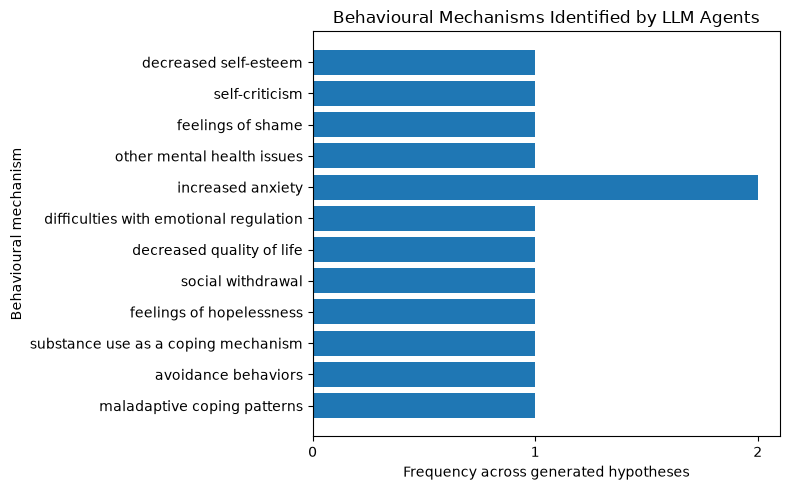

In [180]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


labels = list(mechanism_counts.keys())
values = list(mechanism_counts.values())


plt.figure(figsize=(8, 5))

plt.barh(labels, values)

plt.xlabel("Frequency across generated hypotheses")
plt.ylabel("Behavioural mechanism")

plt.title(
    "Behavioural Mechanisms Identified by LLM Agents"
)

# Force whole numbers on frequency axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()


plt.savefig(
    "figures/behavioural_mechanisms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(mechanism_counts)

Counter({'increased anxiety': 2, 'maladaptive coping patterns': 1, 'avoidance behaviors': 1, 'substance use as a coping mechanism': 1, 'feelings of hopelessness': 1, 'social withdrawal': 1, 'decreased quality of life': 1, 'difficulties with emotional regulation': 1, 'other mental health issues': 1, 'feelings of shame': 1, 'self-criticism': 1, 'decreased self-esteem': 1})


In [181]:
import pandas as pd

pd.DataFrame(
    mechanism_counts.items(),
    columns=["mechanism", "frequency"]
).to_csv(
    "outputs/mechanism_frequency.csv",
    index=False
)

#### Identified challenges by frequency (not displayed due to diverse set of challenges)

In [190]:
from collections import Counter

challenges = []

for r in results:

    behavioural = r.get("behavioural")

    if behavioural is not None:
        challenges.extend(
            behavioural["mechanisms"]
        )

challenge_counts = Counter(challenges)

challenge_counts

Counter({'avoidance (of underlying issues)': 1,
         'rumination (on feelings of hopelessness and shame)': 1,
         'social withdrawal (due to feelings of anxiety and helplessness)': 1,
         'emotion regulation difficulties (evidenced by self-medication with alcohol)': 1,
         'coping pattern: maladaptive coping (self-medication with alcohol)': 1,
         'coping pattern: lack of problem-focused coping (limited access to education and financial instability not addressed)': 1,
         'coping pattern: avoidance of challenges (limited access to education and financial instability not addressed)': 1,
         'avoidance (e.g., difficulty sleeping, seeking distraction)': 1,
         'rumination (e.g., feeling like life is ending, overwhelmed)': 1,
         'social withdrawal (e.g., loss of control, anxiety)': 1,
         'emotion regulation difficulties (e.g., anxiety, fear, panic attacks)': 1,
         'coping pattern difficulties (e.g., ineffective coping strategies, see

In [188]:
results[0].keys()

dict_keys(['id', 'text', 'narrative', 'behavioural', 'intervention', 'evidence'])

#### Proposed interventions by frequency

In [192]:
interventions = []

for r in results:

    intervention_data = r.get("intervention")

    if intervention_data is None:
        continue

    for item in intervention_data["interventions"]:
        interventions.append(
            item["name"]
        )

intervention_counts = Counter(interventions)

intervention_counts

Counter({'Dialectical Behavior Therapy (DBT)': 9,
         'Cognitive-Behavioral Therapy (CBT)': 8,
         'Mindfulness-Based Stress Reduction (MBSR)': 8,
         'Acceptance and Commitment Therapy (ACT)': 4,
         'Exposure Therapy': 3,
         'Motivational Interviewing (MI)': 3,
         'Solution-Focused Brief Therapy (SFBT)': 1,
         'Trauma-Informed Care (TIC)': 1,
         'Social Skills Training': 1,
         'Family-Based Therapy': 1,
         'Mindfulness-Based Cognitive Therapy (MBCT)': 1,
         'Eye Movement Desensitization and Reprocessing (EMDR) Therapy': 1,
         'Cognitive Behavioral Therapy for Insomnia (CBT-I)': 1,
         'Medication Management Therapy': 1})

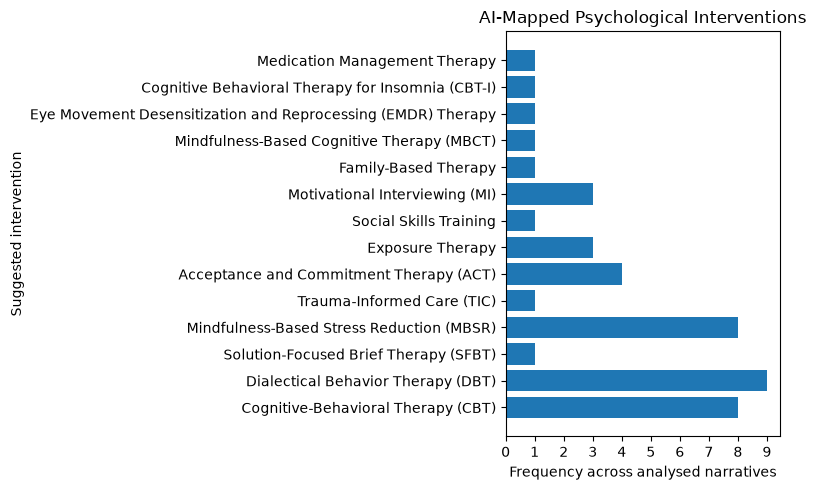

In [193]:
labels = list(intervention_counts.keys())
values = list(intervention_counts.values())


plt.figure(figsize=(8, 5))

plt.barh(labels, values)

plt.xlabel("Frequency across analysed narratives")
plt.ylabel("Suggested intervention")

plt.title(
    "AI-Mapped Psychological Interventions"
)

plt.gca().xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

plt.tight_layout()


plt.savefig(
    "figures/identified_interventions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [194]:
pd.DataFrame(
    intervention_counts.items(),
    columns=["intervention", "frequency"]
).to_csv(
    "outputs/intervention_frequency.csv",
    index=False
)